# WHS NLP Capstone – Notebook 3: RoBERTa Embeddings + SHAP Explainability
This notebook:
- Loads the synthetic dataset
- Generates sentence embeddings using `sentence-transformers` RoBERTa model
- Trains logistic regression models for `effort` and `action_quality`
- Applies SHAP explainability
- Shows feature contributions by persona

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sentence_transformers import SentenceTransformer
import shap
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('synthetic_whs_incidents_persona_dataset.csv')
df['effort'] = df['effort'].str.strip().str.lower()
df['action_quality'] = df['action_quality'].str.strip().str.lower()
df['effort_encoded'] = df['effort'].map({'low': 0, 'medium': 1, 'high': 2})
df['action_quality_encoded'] = df['action_quality'].map({'poor': 0, 'good': 1})
df = df.dropna(subset=['effort_encoded', 'action_quality_encoded'])

In [2]:
# Generate RoBERTa embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
X_roberta = model.encode(df['corrective_action'], show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\krist\miniconda3\envs\whs_model\lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\krist\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [3]:
# Classification for action quality
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X_roberta, df['action_quality_encoded'], test_size=0.3, random_state=42)
clf_quality = LogisticRegression(max_iter=1000)
clf_quality.fit(X_train_q, y_train_q)
y_pred_q = clf_quality.predict(X_test_q)
print('RoBERTa + Logistic Regression – Action Quality')
print(classification_report(y_test_q, y_pred_q))

RoBERTa + Logistic Regression – Action Quality
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        85

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



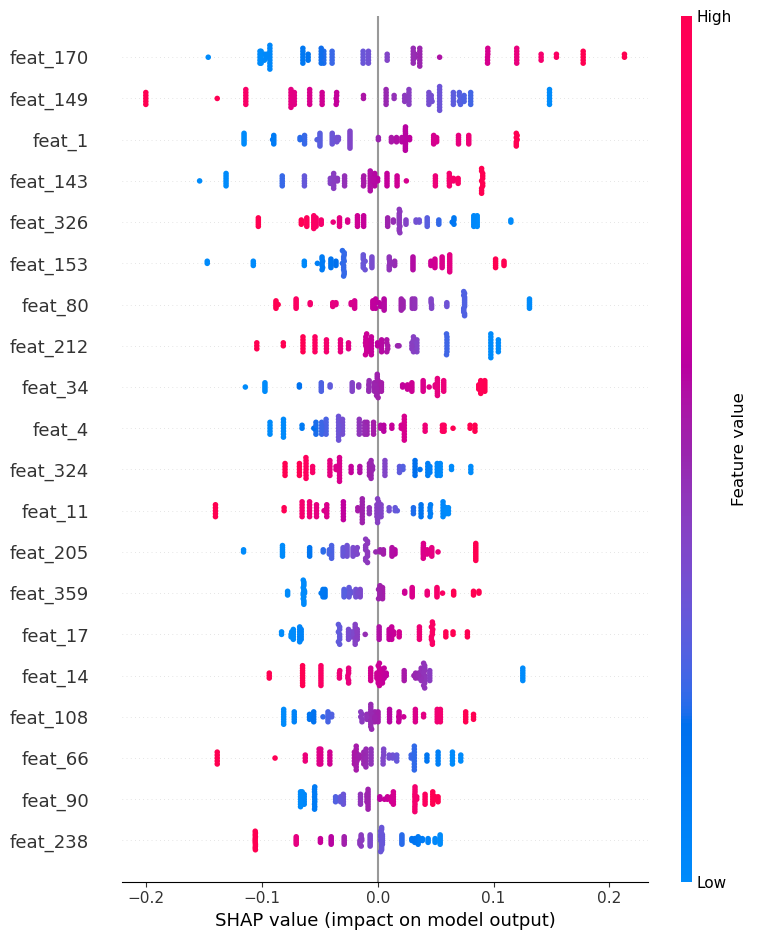

In [4]:
# SHAP explainability
explainer = shap.Explainer(clf_quality, X_train_q)
shap_values = explainer(X_test_q[:100])  # Limit to 100 samples for speed

shap.summary_plot(shap_values, features=X_test_q[:100], feature_names=[f'feat_{i}' for i in range(X_roberta.shape[1])])

                    mean  count
persona                        
Talia Navarro   0.911069    100
Mia Chen        0.879149    100
Kavita Rao      0.873080    100
Gavin Leung     0.204613    100
Barry Thompson  0.145044    100


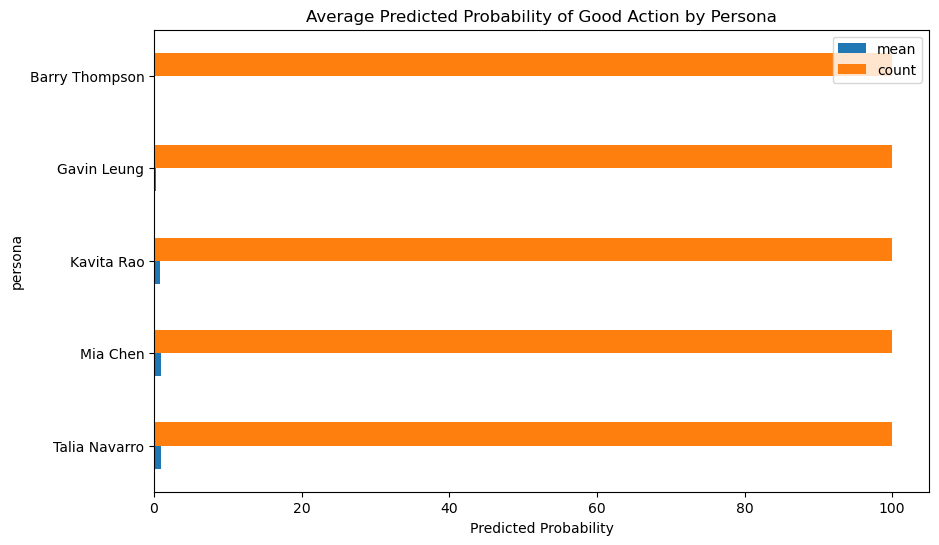

In [5]:
# Group by persona for mean prediction probabilities
from sklearn.preprocessing import MinMaxScaler

df['prob_good_action'] = clf_quality.predict_proba(X_roberta)[:,1]
grouped = df.groupby('persona')['prob_good_action'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
print(grouped)

grouped.plot(kind='barh', figsize=(10, 6), legend=True)
plt.title('Average Predicted Probability of Good Action by Persona')
plt.xlabel('Predicted Probability')
plt.show()

##  Effort Classification and SHAP Analysis

In [6]:
# Classification for effort
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_roberta, df['effort_encoded'], test_size=0.3, random_state=42)
clf_effort = LogisticRegression(max_iter=1000)
clf_effort.fit(X_train_e, y_train_e)
y_pred_e = clf_effort.predict(X_test_e)
print('RoBERTa + Logistic Regression – Effort')
print(classification_report(y_test_e, y_pred_e))

RoBERTa + Logistic Regression – Effort
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        31
           2       1.00      1.00      1.00        54

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



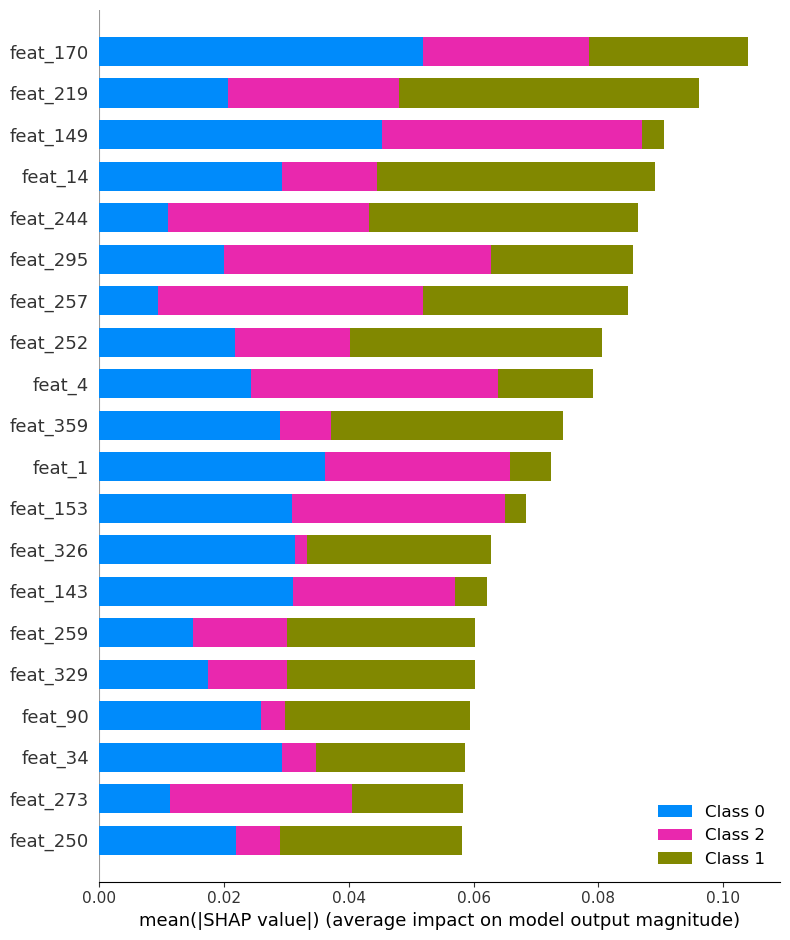

In [7]:
# SHAP for effort
explainer_effort = shap.Explainer(clf_effort, X_train_e)
shap_values_effort = explainer_effort(X_test_e[:100])
shap.summary_plot(shap_values_effort, features=X_test_e[:100], feature_names=[f'feat_{i}' for i in range(X_roberta.shape[1])])

## Psychological Safety Classification and SHAP

In [8]:
# Encode and classify psych_safety
df['psych_safety'] = df['psych_safety'].str.strip().str.lower()
safety_map = {'low': 0, 'mixed': 1, 'medium': 2, 'high': 3}
df['psych_safety_encoded'] = df['psych_safety'].map(safety_map)
df = df.dropna(subset=['psych_safety_encoded'])

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_roberta, df['psych_safety_encoded'], test_size=0.3, random_state=42)
clf_safety = LogisticRegression(max_iter=1000)
clf_safety.fit(X_train_s, y_train_s)
y_pred_s = clf_safety.predict(X_test_s)
print('RoBERTa + Logistic Regression – Psychological Safety')
print(classification_report(y_test_s, y_pred_s))

RoBERTa + Logistic Regression – Psychological Safety
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        31
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        54

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



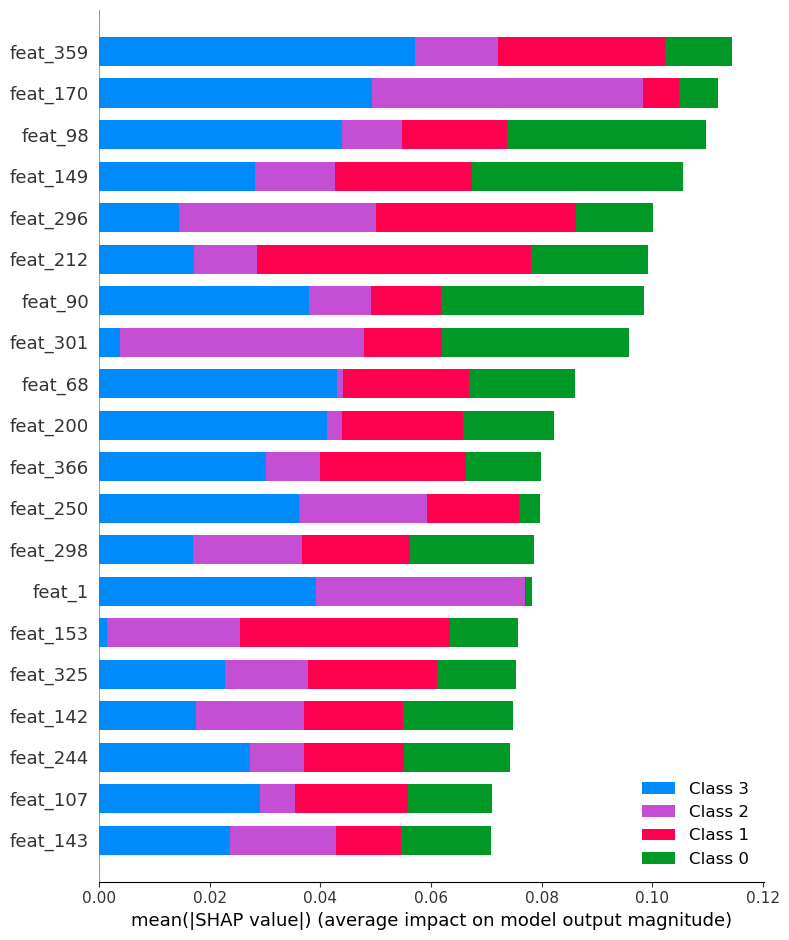

In [9]:
# SHAP for psychological safety
explainer_safety = shap.Explainer(clf_safety, X_train_s)
shap_values_safety = explainer_safety(X_test_s[:100])
shap.summary_plot(shap_values_safety, features=X_test_s[:100], feature_names=[f'feat_{i}' for i in range(X_roberta.shape[1])])